# Amortized Posterior Sampling

This demo learns conditional posterior samplers for the BOD inverse problem. Instead of retraining a sampler for one fixed observation $y$, an amortized method trains one observation-dependent map that can be reused for new observations. The first method is a conditional normalizing flow: it learns an invertible map $T_\theta(z;y)$ from a Gaussian reference draw $z\sim\mathcal{N}(0,I_2)$ to posterior coordinates. The second method is a likelihood-free energy-distance transport map: it learns an MLP map $T_\theta(u;y^\dagger)$ that pushes prior samples $u\sim\rho$ toward the posterior associated with the conditioning observation $y^\dagger$.

The mathematical distinction from the fixed-observation transport demo is important. There the target was one posterior $\pi^y$ and the flow was trained with a reverse-KL variational objective. Here the conditional flow is trained by likelihood-based learning from simulator-generated joint samples, corresponding to an expected forward KL from the true conditional posterior to the learned conditional density. The energy-distance MLP method instead uses joint samples and a metric between probability measures, so it does not require likelihood evaluation, invertibility, or Jacobian determinant computations.

The energy-distance method below is based on Hojjat Kaveh, Ricardo Baptista, and Andrew M. Stuart, [*Amortized Energy-Based Bayesian Inference*](https://arxiv.org/abs/2605.15407).

See Chapter 4: Transport To The Posterior; Chapter 5, Section 5.4: Likelihood-Based Inference; Chapter 5, Section 5.5: Likelihood-Free Inference; Chapter 11, Section 11.1.5: Maximum Mean Discrepancy And Energy Distance; and Chapter 13, Section 13.3: Normalizing Flows.


## Conditional BOD posterior

The simulator defines a joint probability model for unknowns and observations. First draw the latent coordinates
$$
u\sim\rho, \qquad \rho(u)=\mathcal{N}(u;0,I_2).
$$
The physical BOD parameters are obtained from the Gaussian coordinates using the standard normal CDF $\Phi$:
$$
A(u_1)=0.4+0.8\Phi(u_1),
\qquad
B(u_2)=0.01+0.3\Phi(u_2).
$$
By the probability integral transform, $\Phi(u_i)\sim\mathrm{Uniform}(0,1)$ when $u_i\sim\mathcal{N}(0,1)$, so this induces
$$
A\sim\mathrm{Uniform}(0.4,1.2),
\qquad
B\sim\mathrm{Uniform}(0.01,0.31).
$$
For $t\in\{1,2,3,4,5\}$, define
$$
\mathfrak{B}(t;u)=A(u_1)\left(1-\exp[-B(u_2)t]\right),
$$
and stack these five values into the forward map
$$
G(u)=
\begin{bmatrix}
\mathfrak{B}(1;u)\\
\mathfrak{B}(2;u)\\
\mathfrak{B}(3;u)\\
\mathfrak{B}(4;u)\\
\mathfrak{B}(5;u)
\end{bmatrix}.
$$
The observation model is
$$
y=G(u)+\eta,
\qquad
\eta\sim\mathcal{N}(0,\Gamma),
\qquad
\Gamma=10^{-3}I_5.
$$
Equivalently, the conditional density of $y$ given $u$ is
$$
\ell(y\mid u)
=\frac{1}{(2\pi)^{5/2}|\Gamma|^{1/2}}
\exp\left(-\frac12\|y-G(u)\|_{\Gamma^{-1}}^2\right).
$$
The joint density is
$$
p(u,y)=\rho(u)\ell(y\mid u),
$$
and the marginal data density is
$$
p(y)=\int_{\mathbb{R}^2}\rho(u)\ell(y\mid u)\,du.
$$
For any realized observation $y$, the conditional posterior is
$$
\pi^y(u)=p(u\mid y)=\frac{\rho(u)\ell(y\mid u)}{p(y)}.
$$
Amortized inference treats $y$ as an input and learns a single conditional density $q_\theta(u\mid y)$ that should approximate this posterior for many possible observations, not just one fixed $y$.


## Conditional normalizing flow

The model is a conditional RealNVP flow. Let
$$
z\sim\varrho, \qquad \varrho=\mathcal{N}(0,I_2),
$$
and define an invertible map in the latent variable $z$ for each fixed observation $y$,
$$
T_\theta(\cdot;y):\mathbb{R}^2\to\mathbb{R}^2.
$$
The conditional approximate posterior is the push-forward
$$
q_\theta(\cdot\mid y) = T_\theta(\cdot;y)_\#\varrho,
\qquad
u=T_\theta(z;y).
$$
For a fixed $y$, the change-of-variables formula gives
$$
q_\theta(u\mid y)
=\varrho(T_\theta^{-1}(u;y))
\left|\det\nabla_uT_\theta^{-1}(u;y)\right|.
$$
The observation $y$ is a condition, not a transformed variable, so the Jacobian is taken only with respect to $u$ or $z$.

### Conditional RealNVP architecture

The map is constructed as a composition of $K$ conditional affine coupling layers,
$$
T_\theta=L_K\circ L_{K-1}\circ\cdots\circ L_1.
$$
The key change from the unconditional RealNVP map is that the scale and translation networks, $s(\cdot)$ and $t(\cdot)$, now also take the observation $y$ as an input.

For a 2D input $z$, the **Conditional Type 1 layer** $L^{(1)}(z, y)$ is:
\begin{equation*}
L^{(1)}(z, y)=
\begin{bmatrix}
z_1\\
z_2\exp(s(z_1, y))+t(z_1, y)
\end{bmatrix}.
\end{equation*}
This layer keeps $z_1$ fixed and uses $z_1$ together with the condition $y$ to scale and translate $z_2$.

The **Conditional Type 2 layer** $L^{(2)}(z, y)$ swaps the roles of the coordinates:
\begin{equation*}
L^{(2)}(z, y)=
\begin{bmatrix}
z_1\exp(s(z_2, y))+t(z_2, y)\\
z_2
\end{bmatrix}.
\end{equation*}
This layer keeps $z_2$ fixed and uses $z_2$ together with $y$ to update $z_1$. Alternating these two layer types lets both coordinates influence each other across the full composition.

The unified masked formulation uses a binary mask $m\in\{0,1\}^2$ and the Hadamard product $\odot$:
$$
L(z;y,m)=m\odot z+(1-m)\odot
\left[z\odot\exp(s(m\odot z, y))+t(m\odot z, y)\right].
$$
For the Conditional Type 1 layer, the Jacobian with respect to $z$ is triangular:
$$
\nabla_zL^{(1)}(z, y)=
\begin{bmatrix}
1&0\\
\frac{\partial}{\partial z_1}\left[z_2\exp(s(z_1, y))+t(z_1, y)\right]&\exp(s(z_1, y))
\end{bmatrix},
$$
so
$$
\log\left|\det\nabla_zL^{(1)}(z, y)\right|=s(z_1, y).
$$
For the masked layer,
$$
\log\left|\det\nabla_zL(z;y,m)\right|
=\sum_{j=1}^2(1-m_j)s_j(m\odot z, y).
$$
For the full composition $T_\theta=L_K\circ\cdots\circ L_1$, the total log determinant is the sum of the layerwise log determinants.

The inverse is closed form. For the Conditional Type 1 layer, if $z'=L^{(1)}(z, y)$, then
$$
(L^{(1)})^{-1}(z', y)=
\begin{bmatrix}
z'_1\\
(z'_2-t(z'_1, y))\exp[-s(z'_1, y)]
\end{bmatrix}.
$$
The code uses this inverse to evaluate $\log q_\theta(u\mid y)$ and to plot the pulled-back latent variables $T_\theta^{-1}(u;y)$.

### Conditional variational objective

There are two related conditional training objectives worth distinguishing. A direct amortized reverse-KL variational objective would minimize
$$
\min_\theta \mathbb{E}_{y\sim p(y)}\left[D_{\mathrm{KL}}(q_\theta(\cdot\mid y)\|\pi^y)\right],
$$
where
$$
q_\theta(u\mid y)=T_\theta(\cdot;y)_\#\varrho.
$$
The resulting loss function $\mathcal{L}_{\mathrm{Amort}}(\theta)$ extends the fixed-observation transport objective by incorporating $y$ as a contextual input:
$$
\mathcal{L}_{\mathrm{Amort}}(\theta)
= -\mathbb{E}_{y\sim p(y)}\mathbb{E}_{z\sim\varrho}
\left[
\log\rho(T_\theta(z;y))+
\log\ell(y\mid T_\theta(z;y))+
\log\left|\det\nabla_zT_\theta(z;y)\right|
\right].
$$
This is the conditional analogue of the fixed-observation transport VI objective.

The experiment below instead uses likelihood-based amortized training from joint simulator samples. For samples
$$
(u^{(i)},y^{(i)})\sim p(u,y)=\rho(u)\ell(y\mid u),
$$
the loss is the negative conditional log likelihood
$$
\widehat{\mathcal{L}}_{\mathrm{NLL}}(\theta)
=-\frac1N\sum_{i=1}^N\log q_\theta(u^{(i)}\mid y^{(i)}).
$$
In population form,
$$
\mathcal{L}_{\mathrm{NLL}}(\theta)
=-\mathbb{E}_{p(u,y)}\left[\log q_\theta(u\mid y)\right]
=-\mathbb{E}_{p(y)}\mathbb{E}_{u\sim\pi^y}\left[\log q_\theta(u\mid y)\right].
$$
Since
$$
D_{\mathrm{KL}}(\pi^y\|q_\theta(\cdot\mid y))
=\mathbb{E}_{u\sim\pi^y}\left[\log\pi^y(u)-\log q_\theta(u\mid y)\right],
$$
minimizing the conditional NLL is equivalent to minimizing
$$
\mathbb{E}_{p(y)}\left[D_{\mathrm{KL}}(\pi^y\|q_\theta(\cdot\mid y))\right]
$$
up to the posterior entropy term $\mathbb{E}_{p(y)}\mathbb{E}_{\pi^y}[\log\pi^y(u)]$, which does not depend on $\theta$. This forward-KL objective encourages the learned conditional density to cover the posterior samples generated by the simulator.

### Contextual embedding

In high-dimensional observation problems, $y$ is often first compressed by an embedding or summary network $h_\phi(y)$, such as a convolutional network or ResNet, before being fed into the coupling layers. The conditional scale and translation networks then have the form
$$
s=s(m\odot z,h_\phi(y)),
\qquad
t=t(m\odot z,h_\phi(y)).
$$
The parameters $\theta$ of the transport map include both the coupling-layer weights and, when present, the embedding-network weights $\phi$. In this small BOD demo, $y\in\mathbb{R}^5$ is fed directly into the scale and translation networks, so the embedding is the identity.

### Training and inference

During training, the simulator provides joint samples
$$
(u^{(i)},y^{(i)})\sim p(u,y),
$$
and the code minimizes the conditional NLL objective above. At test time, for a new observation $y^*$, posterior samples are obtained without retraining by drawing
$$
z^{(i)}\sim\varrho
$$
and pushing them through the trained conditional map,
$$
u^{(i)}=T_{\widehat{\theta}}(z^{(i)};y^*)\sim q_{\widehat{\theta}}(\cdot\mid y^*)\approx\pi^{y^*}.
$$
The `evaluation_case` control decides whether to inspect one observation or compare three observations with the same trained flow.

**Parameter exploration.**

- Toggle `force_retrain` only when you want to ignore an existing checkpoint and rerun training with the displayed settings.
- Adjust `n_epochs`. Short training often captures broad conditional trends; longer training sharpens the conditional samples and improves the black flow contours.
- Adjust `n_layers` and `hidden_dim`. More capacity can adapt to a wider range of observations, but it can also overfit noisy minibatches or train more slowly.
- Adjust `batch_size`. Larger minibatches reduce noise in the conditional likelihood objective; smaller minibatches train faster per epoch but make the curve less smooth.
- Adjust `evaluation_case`. The important amortization check is that one trained flow is reused across low, standard, and high observations without retraining.

**Recommended test combinations.**

Keep unspecified controls at their displayed defaults.

| `evaluation_case` | `n_layers` | `hidden_dim` | `learning_rate` | `n_epochs` |
|---|---:|---:|---:|---:|
| Compare three cases | 4 | 64 | 0.0010 | 450 |
| Standard BOD observation | 6 | 96 | 0.0008 | 700 |
| Compare three cases | 6 | 96 | 0.0008 | 900 |


Loaded checkpoint: checkpoints/amortized_posterior_sampling/conditional_realnvp/0974319726cb.pt


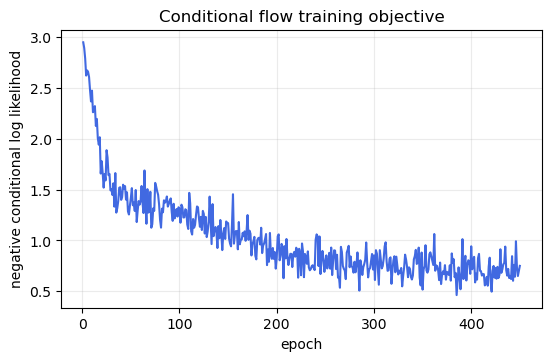

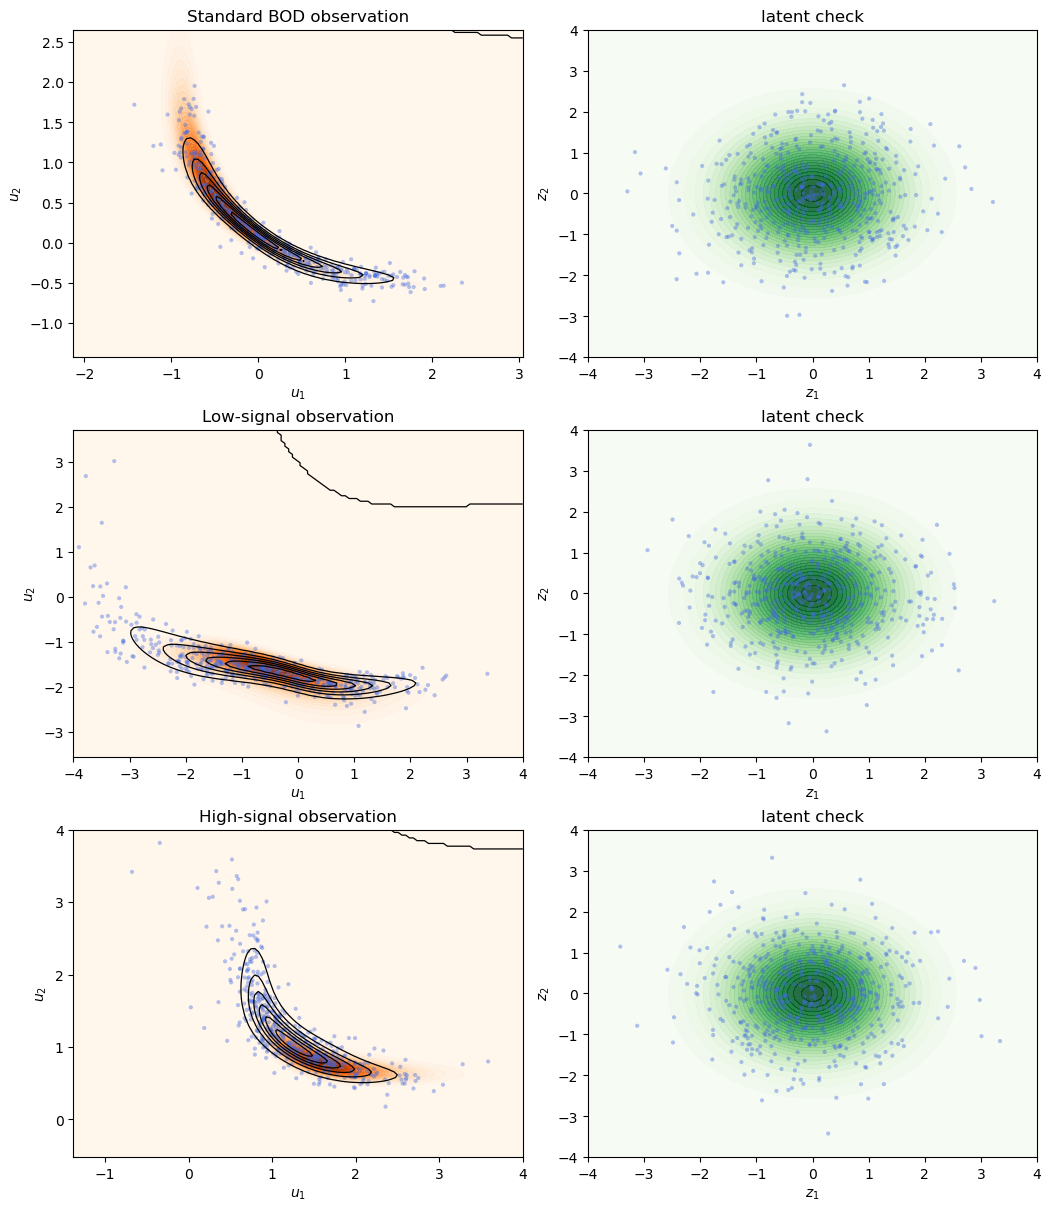

Evaluation: Compare three cases
Average first 30 NLL values: 2.118
Average final 30 NLL values: 0.713
The same trained conditional map was used for every plotted observation.


In [1]:
#@title Amortized posterior sampling with a conditional RealNVP
import math
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.distributions as dist
import matplotlib.pyplot as plt

from pathlib import Path
import hashlib
import json

def checkpoint_path(method_name, params):
    cache_params = {k: v for k, v in params.items() if k != "force_retrain"}
    encoded = json.dumps(cache_params, sort_keys=True).encode("utf-8")
    cache_key = hashlib.sha256(encoded).hexdigest()[:12]
    cache_dir = Path("checkpoints") / "amortized_posterior_sampling" / method_name
    cache_dir.mkdir(parents=True, exist_ok=True)
    return cache_dir / f"{cache_key}.pt"

def load_checkpoint(path):
    try:
        return torch.load(path, map_location="cpu", weights_only=False)
    except TypeError:
        return torch.load(path, map_location="cpu")
from tqdm.auto import tqdm

OBSERVATIONS = {
    "Standard BOD observation": torch.tensor([0.1615, 0.1868, 0.3949, 0.3728, 0.4177], dtype=torch.float32),
    "Low-signal observation": torch.tensor([-0.0072, 0.0427, 0.0505, 0.0638, 0.0729], dtype=torch.float32),
    "High-signal observation": torch.tensor([0.2000, 0.4000, 0.6000, 0.7500, 0.8500], dtype=torch.float32),
}

class BODPosterior:
    def __init__(self, y, gamma_var=1e-3):
        self.y = torch.as_tensor(y, dtype=torch.float32).flatten()
        self.gamma_var = torch.tensor(float(gamma_var), dtype=torch.float32)
        self.obs_time = torch.arange(1, 6, dtype=torch.float32)
        self.prior = dist.MultivariateNormal(torch.zeros(2), torch.eye(2))
        self.standard_normal = dist.Normal(torch.tensor(0.0), torch.tensor(1.0))

    def physical_parameters(self, u):
        u = torch.atleast_2d(torch.as_tensor(u, dtype=torch.float32))
        cdf_vals = self.standard_normal.cdf(u)
        A = 0.4 + 0.8 * cdf_vals[:, 0]
        B = 0.01 + 0.3 * cdf_vals[:, 1]
        return A, B

    def forward_model(self, u):
        u = torch.atleast_2d(torch.as_tensor(u, dtype=torch.float32))
        A, B = self.physical_parameters(u)
        return A[:, None] * (1.0 - torch.exp(-B[:, None] * self.obs_time[None, :]))

    def log_prob(self, u):
        u = torch.atleast_2d(torch.as_tensor(u, dtype=torch.float32))
        residual = self.y[None, :] - self.forward_model(u)
        log_likelihood = -0.5 * torch.sum(residual * residual, dim=1) / self.gamma_var
        return log_likelihood + self.prior.log_prob(u)

    def potential(self, u):
        return -self.log_prob(torch.atleast_2d(u))[0]

    def grid(self, domain_x1=(-1.5, 1.5), domain_x2=(-0.75, 2.25), n_grid=120):
        x1 = torch.linspace(domain_x1[0], domain_x1[1], n_grid)
        x2 = torch.linspace(domain_x2[0], domain_x2[1], n_grid)
        X1, X2 = torch.meshgrid(x1, x2, indexing="ij")
        points = torch.stack([X1.reshape(-1), X2.reshape(-1)], dim=1)
        with torch.no_grad():
            logp = self.log_prob(points)
            density = torch.exp(logp - logp.max()).reshape(n_grid, n_grid).cpu().numpy()
        return X1.cpu().numpy(), X2.cpu().numpy(), density, points

    def plot_density(self, ax, domain_x1=(-1.5, 1.5), domain_x2=(-0.75, 2.25), n_grid=120, title=None):
        X1, X2, density, _ = self.grid(domain_x1, domain_x2, n_grid)
        ax.contourf(X1, X2, density, levels=35, cmap="Oranges", alpha=0.82)
        ax.contour(X1, X2, density, levels=7, colors="saddlebrown", linewidths=0.5, alpha=0.55)
        ax.set_xlabel("$u_1$")
        ax.set_ylabel("$u_2$")
        ax.set_xlim(domain_x1)
        ax.set_ylim(domain_x2)
        if title is not None:
            ax.set_title(title)

DEFAULTS = {
    "evaluation_case": "Compare three cases",
    "n_layers": 4,
    "hidden_dim": 64,
    "learning_rate": 0.001,
    "n_epochs": 450,
    "batch_size": 192,
    "n_samples": 500,
    "force_retrain": False,
    "seed": 11,
}

use_default = False #@param {type:"boolean"}
force_retrain = False #@param {type:"boolean"}
evaluation_case = "Compare three cases" #@param ["Compare three cases", "Standard BOD observation", "Low-signal observation", "High-signal observation"]
n_layers = 4 #@param {type:"slider", min:2, max:8, step:2}
hidden_dim = 64 #@param {type:"slider", min:16, max:160, step:16}
learning_rate = 0.001 #@param {type:"slider", min:0.0002, max:0.0030, step:0.0002}
n_epochs = 450 #@param {type:"slider", min:100, max:1200, step:50}
batch_size = 192 #@param {type:"slider", min:64, max:512, step:32}
n_samples = 500 #@param {type:"slider", min:100, max:1500, step:100}

params = DEFAULTS.copy()
if not use_default:
    params.update({
        "evaluation_case": evaluation_case,
        "n_layers": int(n_layers),
        "hidden_dim": int(hidden_dim),
        "learning_rate": float(learning_rate),
        "n_epochs": int(n_epochs),
        "batch_size": int(batch_size),
        "n_samples": int(n_samples),
        "force_retrain": bool(force_retrain),
    })

torch.manual_seed(params["seed"])
np.random.seed(params["seed"])
simulator = BODPosterior(OBSERVATIONS["Standard BOD observation"])

def sample_joint(batch_size):
    u = simulator.prior.sample((batch_size,))
    y_clean = simulator.forward_model(u)
    y = y_clean + torch.randn_like(y_clean) * torch.sqrt(simulator.gamma_var)
    return u, y

class ConditionalRealNVP(nn.Module):
    def __init__(self, n_layers, hidden_dim, scale_bound=0.8):
        super().__init__()
        self.ref = dist.MultivariateNormal(torch.zeros(2), torch.eye(2))
        self.scale_bound = scale_bound
        self.context_dim = 5
        masks = [[0.0, 1.0], [1.0, 0.0]] * (n_layers // 2)
        self.register_buffer("masks", torch.tensor(masks, dtype=torch.float32))

        def make_net(use_tanh=False):
            layers = [nn.Linear(2 + self.context_dim, hidden_dim), nn.Tanh(), nn.Linear(hidden_dim, hidden_dim), nn.Tanh(), nn.Linear(hidden_dim, 2)]
            if use_tanh:
                layers.append(nn.Tanh())
            return nn.Sequential(*layers)

        self.s = nn.ModuleList([make_net(use_tanh=True) for _ in range(n_layers)])
        self.t = nn.ModuleList([make_net(use_tanh=False) for _ in range(n_layers)])

    def T(self, z, y):
        x = z
        for i, mask in enumerate(self.masks):
            x_masked = x * mask
            context = torch.cat([x_masked, y], dim=1)
            s = self.scale_bound * self.s[i](context) * (1.0 - mask)
            t = self.t[i](context) * (1.0 - mask)
            x = x_masked + (1.0 - mask) * (x * torch.exp(s) + t)
        return x

    def Tinv(self, x, y):
        log_det = x.new_zeros(x.shape[0])
        z = x
        for i in reversed(range(len(self.s))):
            mask = self.masks[i]
            z_masked = z * mask
            context = torch.cat([z_masked, y], dim=1)
            s = self.scale_bound * self.s[i](context) * (1.0 - mask)
            t = self.t[i](context) * (1.0 - mask)
            z = z_masked + (1.0 - mask) * (z - t) * torch.exp(-s)
            log_det = log_det - s.sum(dim=1)
        return z, log_det

    def log_prob(self, u, y):
        z, log_det_inv = self.Tinv(u, y)
        return self.ref.log_prob(z) + log_det_inv

    def sample(self, n_samples, y):
        y = torch.as_tensor(y, dtype=torch.float32)
        if y.ndim == 1:
            y = y[None, :]
        if y.shape[0] == 1:
            y = y.repeat(n_samples, 1)
        z = self.ref.sample((n_samples,))
        return self.T(z, y)

flow = ConditionalRealNVP(params["n_layers"], params["hidden_dim"])
optimizer = optim.Adam(flow.parameters(), lr=params["learning_rate"])
losses = []
ckpt_path = checkpoint_path("conditional_realnvp", params)
ckpt = None if params["force_retrain"] or not ckpt_path.exists() else load_checkpoint(ckpt_path)

if ckpt is not None:
    flow.load_state_dict(ckpt["model_state"])
    losses = ckpt["losses"]
    print(f"Loaded checkpoint: {ckpt_path}")
else:
    progress = tqdm(range(params["n_epochs"]), desc="Training conditional RealNVP", leave=False)
    for epoch in progress:
        u_batch, y_batch = sample_joint(params["batch_size"])
        loss = -flow.log_prob(u_batch, y_batch).mean()
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(flow.parameters(), 5.0)
        optimizer.step()
        current_loss = float(loss.detach())
        losses.append(current_loss)
        if epoch == 0 or (epoch + 1) % 10 == 0:
            progress.set_postfix(loss=f"{current_loss:.3f}")
    torch.save({"params": params, "model_state": flow.state_dict(), "losses": losses}, ckpt_path)
    print(f"Saved checkpoint: {ckpt_path}")

fig, ax = plt.subplots(figsize=(5.4, 3.5), constrained_layout=True)
ax.plot(np.arange(1, len(losses) + 1), losses, color="royalblue")
ax.set_xlabel("epoch")
ax.set_ylabel("negative conditional log likelihood")
ax.set_title("Conditional flow training objective")
ax.grid(alpha=0.25)
plt.show()

def domain_from_samples(samples, margin=0.7):
    low = samples.min(dim=0).values - margin
    high = samples.max(dim=0).values + margin
    low = torch.maximum(low, torch.tensor([-4.0, -4.0]))
    high = torch.minimum(high, torch.tensor([4.0, 4.0]))
    return (float(low[0]), float(high[0])), (float(low[1]), float(high[1]))

def evaluate_case(ax_u, ax_z, case_name, y_value):
    posterior = BODPosterior(y_value)
    with torch.no_grad():
        samples = flow.sample(params["n_samples"], y_value)
        y_context = torch.as_tensor(y_value, dtype=torch.float32)[None, :].repeat(params["n_samples"], 1)
        z_back, _ = flow.Tinv(samples, y_context)

    domain_x1, domain_x2 = domain_from_samples(samples)
    X1, X2, true_density, grid_points = posterior.grid(domain_x1, domain_x2, n_grid=120)
    y_grid = torch.as_tensor(y_value, dtype=torch.float32)[None, :].repeat(grid_points.shape[0], 1)
    with torch.no_grad():
        log_q = flow.log_prob(grid_points, y_grid)
        q_density = torch.exp(log_q - log_q.max()).reshape(X1.shape).cpu().numpy()

    ax_u.contourf(X1, X2, true_density, levels=35, cmap="Oranges", alpha=0.80)
    ax_u.contour(X1, X2, q_density, levels=7, colors="black", linewidths=0.9)
    ax_u.scatter(samples[:, 0], samples[:, 1], s=9, c="royalblue", alpha=0.40, edgecolors="none")
    ax_u.set_title(case_name)
    ax_u.set_xlabel("$u_1$")
    ax_u.set_ylabel("$u_2$")
    ax_u.set_xlim(domain_x1)
    ax_u.set_ylim(domain_x2)

    z1 = torch.linspace(-4.0, 4.0, 100)
    z2 = torch.linspace(-4.0, 4.0, 100)
    Z1, Z2 = torch.meshgrid(z1, z2, indexing="ij")
    zz = torch.stack([Z1.reshape(-1), Z2.reshape(-1)], dim=1)
    with torch.no_grad():
        ref_density = torch.exp(flow.ref.log_prob(zz)).reshape(100, 100).cpu().numpy()
    ax_z.contourf(Z1.numpy(), Z2.numpy(), ref_density, levels=30, cmap="Greens", alpha=0.85)
    ax_z.scatter(z_back[:, 0], z_back[:, 1], s=9, c="royalblue", alpha=0.40, edgecolors="none")
    ax_z.set_xlim(-4, 4)
    ax_z.set_ylim(-4, 4)
    ax_z.set_xlabel("$z_1$")
    ax_z.set_ylabel("$z_2$")
    ax_z.set_title("latent check")

if params["evaluation_case"] == "Compare three cases":
    cases = list(OBSERVATIONS.items())
else:
    cases = [(params["evaluation_case"], OBSERVATIONS[params["evaluation_case"]])]

fig, axes = plt.subplots(len(cases), 2, figsize=(10.4, 4.0 * len(cases)), constrained_layout=True)
if len(cases) == 1:
    axes = np.asarray([axes])
for row, (case_name, y_value) in enumerate(cases):
    evaluate_case(axes[row, 0], axes[row, 1], case_name, y_value)
plt.show()

print(f"Evaluation: {params['evaluation_case']}")
print(f"Average first 30 NLL values: {np.mean(losses[:30]):.3f}")
print(f"Average final 30 NLL values: {np.mean(losses[-30:]):.3f}")
print("The same trained conditional map was used for every plotted observation.")


## Energy-distance MLP transport map

The conditional flow above is likelihood-based and invertible. We now consider a likelihood-free transport objective based on the paper [*Amortized Energy-Based Bayesian Inference*](https://arxiv.org/abs/2605.15407). Let $\mathcal U$ be the state space and let $\mathcal Y$ be the observation space. The joint law of states and observations is
$$
\gamma(u,y)=\rho(u)\ell(y\mid u)=\pi(u\mid y)\kappa(y),
$$
where $\rho$ is the prior, $\ell(y\mid u)$ is the likelihood kernel, $\pi(\cdot\mid y)$ is the posterior, and $\kappa$ is the marginal law of observations. In this demo, $\pi^y$ and $\pi(\cdot\mid y)$ denote the same conditional posterior.

The energy distance between two probability measures $\bar\pi$ and $\pi$ with finite first moments is
$$
D_E^2(\bar\pi,\pi)
=2\,\mathbb{E}_{(u,v)\sim\bar\pi\otimes\pi}[\|u-v\|]
-\mathbb{E}_{(u,u')\sim\bar\pi\otimes\bar\pi}[\|u-u'\|]
-\mathbb{E}_{(v,v')\sim\pi\otimes\pi}[\|v-v'\|].
$$
For amortized posterior sampling, the ideal objective averages this distance over the observation distribution:
$$
L(\theta)
=\mathbb{E}^{y^\dagger\sim\kappa(y)}
\left[
D_E^2\left(
\tilde\pi_\theta(\cdot\mid y^\dagger),
\pi(\cdot\mid y^\dagger)
\right)
\right].
$$

A fully joint-sample version uses a map
$$
T_\theta:\mathcal U\times\mathcal Y\times\mathcal Y\to\mathcal U,
$$
which transports a simulated pair $(u,y)\sim\gamma$ to the posterior for a new conditioning value $y^\dagger$. The learned posterior is
$$
\tilde\pi_\theta(\cdot\mid y^\dagger)
=T_\theta(\cdot,\cdot;y^\dagger)_\#\gamma.
$$
After dropping the posterior-posterior energy term, which is independent of $\theta$, minimizing $L(\theta)$ is equivalent to minimizing
$$
J(\theta)
=2\mathbb{E}^{((u,y),(v,y'))\sim(\gamma\otimes\gamma)}
\|T_\theta(u,y;y')-v\|
-\mathbb{E}^{((u,y),(u',y'),y'')\sim(\gamma\otimes\gamma\otimes\kappa)}
\|T_\theta(u,y;y'')-T_\theta(u',y';y'')\|.
$$

For the BOD experiment below, we use the prior as the reference distribution because we can sample $u\sim\rho$ directly. For each $y^\dagger$, define
$$
\tilde\pi_\theta(\cdot\mid y^\dagger)
=T_\theta(\cdot;y^\dagger)_\#\rho,
\qquad
T_\theta(\cdot;y^\dagger):\mathcal U\to\mathcal U.
$$
Then the trainable population objective can be written using only $\rho$, $\gamma$, and $\kappa$:
$$
J(\theta)
=2\mathbb{E}^{(u,(u',y'))\sim(\rho\otimes\gamma)}
\|T_\theta(u;y')-u'\|
-\mathbb{E}^{(u,u',y'')\sim(\rho\otimes\rho\otimes\kappa)}
\|T_\theta(u;y'')-T_\theta(u';y'')\|.
$$
The first term moves transported prior samples toward states paired with the conditioning observation. The second term keeps the transported samples spread out for each fixed $y^\dagger$, preventing collapse to a point estimate.

Given $N$ joint samples $\{(u^{(i)},y^{(i)})\}_{i=1}^N$, the empirical objective used in minibatches is
$$
\begin{aligned}
\widehat J(\theta)
&=\frac{2}{N(N-1)}\sum_{\substack{i,j=1\\ i\neq j}}^N
\left\|T_\theta\left(u^{(i)};y^{(j)}\right)-u^{(j)}\right\| \\\\
&\quad -\frac{1}{N(N-1)(N-2)}\sum_{\substack{i,j,k=1\\ i\neq j,\ i\neq k,\ j\neq k}}^N
\left\|T_\theta\left(u^{(i)};y^{(k)}\right)-T_\theta\left(u^{(j)};y^{(k)}\right)\right\|.
\end{aligned}
$$
The code represents $T_\theta$ by a small MLP with input $(u,y^\dagger)\in\mathbb{R}^{2+5}$ and output in $\mathbb{R}^2$. Because this map is not required to be invertible, the plots show transported samples over the true posterior contours rather than learned density contours.

**Parameter exploration.**

- Toggle `force_retrain` only when you want to ignore an existing checkpoint and rerun training with the displayed settings.
- Adjust `learning_rate`. In local tests, values near `0.0012` gave a better balance than larger values: the training loss still decreased, while the high-signal posterior samples did not drift as far from the observation.
- Adjust `n_epochs`. Early training usually moves samples toward the correct observation-dependent region; longer training improves concentration but can become noisier because the objective estimates pairwise distances from minibatches.
- Adjust `batch_size`. Larger minibatches give a less noisy empirical energy-distance estimate, but the spread term scales cubically with the batch size; in this demo, `96` is a useful speed-accuracy compromise.
- Adjust `n_samples`. This controls how many transported prior samples are shown in the posterior plots, not the training batch size. Larger values make the plotted sample cloud more stable.
- Adjust `evaluation_case`. The amortization check is whether the same trained MLP produces different transported prior clouds for low, standard, and high observations without retraining.

**Recommended test combinations.**

Keep unspecified controls at their displayed defaults.

| `evaluation_case` | `hidden_dim` | `num_hidden_layers` | `learning_rate` | `n_epochs` | `n_samples` |
|---|---:|---:|---:|---:|---:|
| Standard BOD observation | 96 | 3 | 0.001 | 1000 | 1000 |



Loaded checkpoint: checkpoints/amortized_posterior_sampling/energy_mlp_transport/48623b03832f.pt


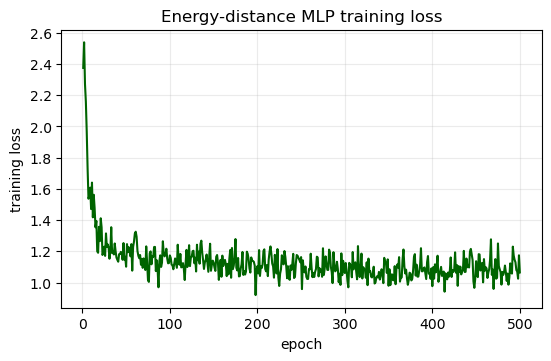

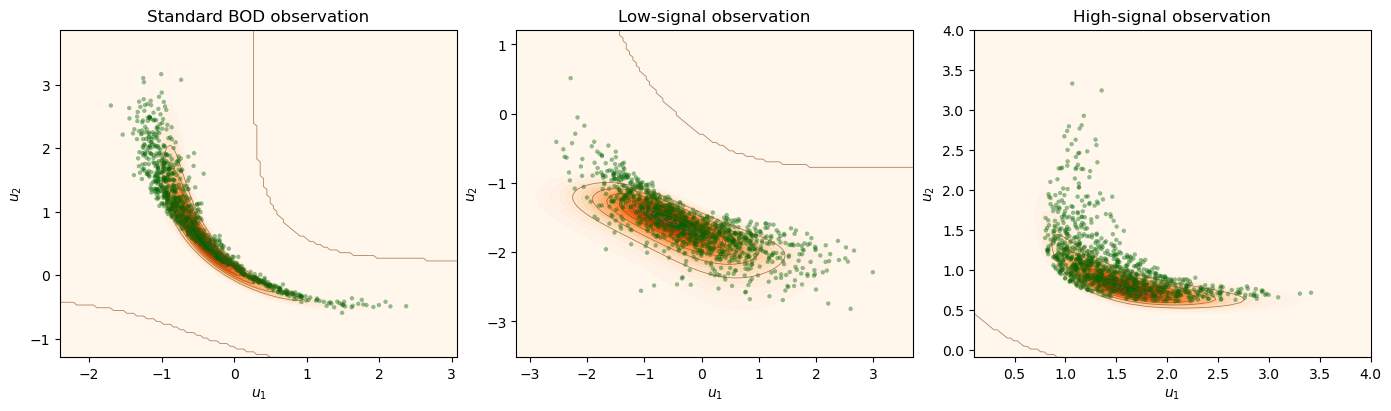

Evaluation: Compare three cases
Average first 30 training-loss values: 1.521
Average final 30 training-loss values: 1.085
Standard BOD observation: sample mean=(-0.459, 0.887), sample std=(0.639, 0.786), ||mean G(u)-y||=0.098
Low-signal observation: sample mean=(-0.166, -1.605), sample std=(0.968, 0.415), ||mean G(u)-y||=0.037
High-signal observation: sample mean=(1.486, 1.066), sample std=(0.463, 0.400), ||mean G(u)-y||=0.092
The same trained MLP transport map was used for every plotted observation.


In [2]:
#@title Amortized energy-distance MLP transport map
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.distributions as dist
import matplotlib.pyplot as plt

from pathlib import Path
import hashlib
import json

def checkpoint_path(method_name, params):
    cache_params = {k: v for k, v in params.items() if k != "force_retrain"}
    encoded = json.dumps(cache_params, sort_keys=True).encode("utf-8")
    cache_key = hashlib.sha256(encoded).hexdigest()[:12]
    cache_dir = Path("checkpoints") / "amortized_posterior_sampling" / method_name
    cache_dir.mkdir(parents=True, exist_ok=True)
    return cache_dir / f"{cache_key}.pt"

def load_checkpoint(path):
    try:
        return torch.load(path, map_location="cpu", weights_only=False)
    except TypeError:
        return torch.load(path, map_location="cpu")
from tqdm.auto import tqdm

OBSERVATIONS = {
    "Standard BOD observation": torch.tensor([0.1615, 0.1868, 0.3949, 0.3728, 0.4177], dtype=torch.float32),
    "Low-signal observation": torch.tensor([-0.0072, 0.0427, 0.0505, 0.0638, 0.0729], dtype=torch.float32),
    "High-signal observation": torch.tensor([0.2000, 0.4000, 0.6000, 0.7500, 0.8500], dtype=torch.float32),
}

class BODPosterior:
    def __init__(self, y, gamma_var=1e-3):
        self.y = torch.as_tensor(y, dtype=torch.float32).flatten()
        self.gamma_var = torch.tensor(float(gamma_var), dtype=torch.float32)
        self.obs_time = torch.arange(1, 6, dtype=torch.float32)
        self.prior = dist.MultivariateNormal(torch.zeros(2), torch.eye(2))
        self.standard_normal = dist.Normal(torch.tensor(0.0), torch.tensor(1.0))

    def physical_parameters(self, u):
        u = torch.atleast_2d(torch.as_tensor(u, dtype=torch.float32))
        cdf_vals = self.standard_normal.cdf(u)
        A = 0.4 + 0.8 * cdf_vals[:, 0]
        B = 0.01 + 0.3 * cdf_vals[:, 1]
        return A, B

    def forward_model(self, u):
        u = torch.atleast_2d(torch.as_tensor(u, dtype=torch.float32))
        A, B = self.physical_parameters(u)
        return A[:, None] * (1.0 - torch.exp(-B[:, None] * self.obs_time[None, :]))

    def log_prob(self, u):
        u = torch.atleast_2d(torch.as_tensor(u, dtype=torch.float32))
        residual = self.y[None, :] - self.forward_model(u)
        log_likelihood = -0.5 * torch.sum(residual * residual, dim=1) / self.gamma_var
        return log_likelihood + self.prior.log_prob(u)

    def grid(self, domain_x1=(-1.5, 1.5), domain_x2=(-0.75, 2.25), n_grid=120):
        x1 = torch.linspace(domain_x1[0], domain_x1[1], n_grid)
        x2 = torch.linspace(domain_x2[0], domain_x2[1], n_grid)
        X1, X2 = torch.meshgrid(x1, x2, indexing="ij")
        points = torch.stack([X1.reshape(-1), X2.reshape(-1)], dim=1)
        with torch.no_grad():
            logp = self.log_prob(points)
            density = torch.exp(logp - logp.max()).reshape(n_grid, n_grid).cpu().numpy()
        return X1.cpu().numpy(), X2.cpu().numpy(), density

# Fixed default parameters for this experiment.
DEFAULTS = {
    "evaluation_case": "Compare three cases",
    "hidden_dim": 96,
    "num_hidden_layers": 3,
    "learning_rate": 0.005,
    "n_epochs": 500,
    "batch_size": 192,
    "n_samples": 1000,
    "output_bound": 5.0,
    "force_retrain": False,
    "seed": 17,
}

use_default = True #@param {type:"boolean"}
force_retrain = False #@param {type:"boolean"}
evaluation_case = "Compare three cases" #@param ["Compare three cases", "Standard BOD observation", "Low-signal observation", "High-signal observation"]
hidden_dim = 96 #@param {type:"slider", min:32, max:192, step:32}
num_hidden_layers = 3 #@param {type:"slider", min:1, max:5, step:1}
learning_rate = 0.0012 #@param {type:"slider", min:0.0002, max:0.0030, step:0.0002}
n_epochs = 500 #@param {type:"slider", min:100, max:1200, step:50}
batch_size = 96 #@param {type:"slider", min:32, max:192, step:32}
n_samples = 1000 #@param {type:"slider", min:200, max:2000, step:100}

params = DEFAULTS.copy()
if not use_default:
    params.update({
        "evaluation_case": evaluation_case,
        "hidden_dim": int(hidden_dim),
        "num_hidden_layers": int(num_hidden_layers),
        "learning_rate": float(learning_rate),
        "n_epochs": int(n_epochs),
        "batch_size": int(batch_size),
        "n_samples": int(n_samples),
        "force_retrain": bool(force_retrain),
    })

torch.manual_seed(params["seed"])
np.random.seed(params["seed"])
simulator = BODPosterior(OBSERVATIONS["Standard BOD observation"])

def sample_joint(n):
    u = simulator.prior.sample((n,))
    y_clean = simulator.forward_model(u)
    y = y_clean + torch.randn_like(y_clean) * torch.sqrt(simulator.gamma_var)
    return u, y

class MLPTransport(nn.Module):
    def __init__(self, hidden_dim, num_hidden_layers, output_bound):
        super().__init__()
        layers = []
        in_dim = 7
        for layer_idx in range(num_hidden_layers):
            layers.append(nn.Linear(in_dim if layer_idx == 0 else hidden_dim, hidden_dim))
            layers.append(nn.GELU())
        layers.append(nn.Linear(hidden_dim, 2))
        self.net = nn.Sequential(*layers)
        self.output_bound = float(output_bound)

    def forward(self, u, y):
        raw = self.net(torch.cat([u, y], dim=1))
        return self.output_bound * torch.tanh(raw / self.output_bound)

def empirical_energy_objective(model, u, y):
    n = u.shape[0]
    eye = torch.eye(n, dtype=torch.bool, device=u.device)

    u_source = u[:, None, :].expand(n, n, 2).reshape(n * n, 2)
    y_target = y[None, :, :].expand(n, n, 5).reshape(n * n, 5)
    mapped_to_targets = model(u_source, y_target).reshape(n, n, 2)
    target_dist = torch.linalg.norm(mapped_to_targets - u[None, :, :], dim=2)
    attraction = target_dist[~eye].mean()

    y_cond = y[:, None, :].expand(n, n, 5).reshape(n * n, 5)
    u_ref = u[None, :, :].expand(n, n, 2).reshape(n * n, 2)
    transported = model(u_ref, y_cond).reshape(n, n, 2)
    pair_dist = torch.linalg.norm(transported[:, :, None, :] - transported[:, None, :, :], dim=3)
    idx = torch.arange(n, device=u.device)
    k = idx[:, None, None]
    i = idx[None, :, None]
    j = idx[None, None, :]
    triple_mask = (i != j) & (i != k) & (j != k)
    spread = pair_dist[triple_mask].mean()
    return 2.0 * attraction - spread

transport = MLPTransport(params["hidden_dim"], params["num_hidden_layers"], params["output_bound"])
optimizer = optim.Adam(transport.parameters(), lr=params["learning_rate"])
losses = []
ckpt_path = checkpoint_path("energy_mlp_transport", params)
ckpt = None if params["force_retrain"] or not ckpt_path.exists() else load_checkpoint(ckpt_path)

if ckpt is not None:
    transport.load_state_dict(ckpt["model_state"])
    losses = ckpt["losses"]
    print(f"Loaded checkpoint: {ckpt_path}")
else:
    progress = tqdm(range(params["n_epochs"]), desc="Training energy MLP", leave=False)
    for epoch in progress:
        u_batch, y_batch = sample_joint(params["batch_size"])
        loss = empirical_energy_objective(transport, u_batch, y_batch)
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(transport.parameters(), 5.0)
        optimizer.step()
        current_loss = float(loss.detach())
        losses.append(current_loss)
        if epoch == 0 or (epoch + 1) % 10 == 0:
            progress.set_postfix(loss=f"{current_loss:.3f}")
    torch.save({"params": params, "model_state": transport.state_dict(), "losses": losses}, ckpt_path)
    print(f"Saved checkpoint: {ckpt_path}")
fig, ax = plt.subplots(figsize=(5.4, 3.5), constrained_layout=True)
ax.plot(np.arange(1, len(losses) + 1), losses, color="darkgreen", label="$\\widehat J(\\theta)$")
ax.set_xlabel("epoch")
ax.set_ylabel("training loss")
ax.set_title("Energy-distance MLP training loss")
ax.grid(alpha=0.25)
plt.show()

def domain_from_samples(samples, margin=0.7):
    low = samples.min(dim=0).values - margin
    high = samples.max(dim=0).values + margin
    low = torch.maximum(low, torch.tensor([-4.0, -4.0]))
    high = torch.minimum(high, torch.tensor([4.0, 4.0]))
    return (float(low[0]), float(high[0])), (float(low[1]), float(high[1]))

def evaluate_case(ax, case_name, y_value):
    posterior = BODPosterior(y_value)
    with torch.no_grad():
        u_ref = simulator.prior.sample((params["n_samples"],))
        y_context = torch.as_tensor(y_value, dtype=torch.float32)[None, :].repeat(params["n_samples"], 1)
        samples = transport(u_ref, y_context)
        y_pred = posterior.forward_model(samples).mean(dim=0)

    domain_x1, domain_x2 = domain_from_samples(samples)
    X1, X2, true_density = posterior.grid(domain_x1, domain_x2, n_grid=120)
    ax.contourf(X1, X2, true_density, levels=35, cmap="Oranges", alpha=0.80)
    ax.contour(X1, X2, true_density, levels=8, colors="saddlebrown", linewidths=0.6, alpha=0.65)
    ax.scatter(samples[:, 0], samples[:, 1], s=10, c="darkgreen", alpha=0.42, edgecolors="none")
    ax.set_title(case_name)
    ax.set_xlabel("$u_1$")
    ax.set_ylabel("$u_2$")
    ax.set_xlim(domain_x1)
    ax.set_ylim(domain_x2)
    return samples.mean(dim=0), samples.std(dim=0), y_pred

if params["evaluation_case"] == "Compare three cases":
    cases = list(OBSERVATIONS.items())
else:
    cases = [(params["evaluation_case"], OBSERVATIONS[params["evaluation_case"]])]

fig, axes = plt.subplots(1, len(cases), figsize=(4.6 * len(cases), 4.0), constrained_layout=True)
axes = np.atleast_1d(axes)
summaries = []
for ax, (case_name, y_value) in zip(axes, cases):
    sample_mean, sample_std, y_pred = evaluate_case(ax, case_name, y_value)
    summaries.append((case_name, sample_mean, sample_std, y_pred, y_value))
plt.show()

print(f"Evaluation: {params['evaluation_case']}")
print(f"Average first 30 training-loss values: {np.mean(losses[:30]):.3f}")
print(f"Average final 30 training-loss values: {np.mean(losses[-30:]):.3f}")
for case_name, sample_mean, sample_std, y_pred, y_value in summaries:
    residual = torch.linalg.norm(y_pred - y_value).item()
    print(
        f"{case_name}: sample mean=({sample_mean[0]:.3f}, {sample_mean[1]:.3f}), "
        f"sample std=({sample_std[0]:.3f}, {sample_std[1]:.3f}), "
        f"||mean G(u)-y||={residual:.3f}"
    )
print("The same trained MLP transport map was used for every plotted observation.")
